In [34]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [20]:
ROOT = Path.cwd().parent.resolve()
RAW_DATA_DIR = ROOT / "data" / "raw"
PROCESSED_DATA_DIR = ROOT / "data" / "processed"
wltp_file = RAW_DATA_DIR / "MLP001_wltp_25degC.xlsx"

In [21]:
# open file using pd read xlsx
df = pd.read_excel(wltp_file, engine="openpyxl", sheet_name="record")
# openpyxl supports newer excel formats.

/Users/williambuesnel/anaconda3/envs/FuseProject/lib/python3.14/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [22]:
print(f"Dataframe shape: {df.shape}")
print(f"Dataframe columns: {df.columns.tolist()}")
print(f"Dataframe head:\n{df.head()}")

Dataframe shape: (395302, 14)
Dataframe columns: ['DataPoint', 'Step Type', 'Time', 'Total Time', 'Current(A)', 'Voltage(V)', 'Capacity(Ah)', 'Energy(Wh)', 'Date', 'Power(W)', 'V1(V)', 'T1(℃)', 'Aux. ΔV(V)', 'Aux. ΔT(℃)']
Dataframe head:
   DataPoint Step Type      Time Total Time  Current(A)  Voltage(V)  \
0          1      Rest  00:00:00   00:00:00         0.0      4.1715   
1          2      Rest  00:00:00   00:00:00         0.0      4.1715   
2          3      Rest  00:00:00   00:00:00         0.0      4.1716   
3          4      Rest  00:00:00   00:00:00         0.0      4.1715   
4          5      Rest  00:00:00   00:00:00         0.0      4.1715   

   Capacity(Ah)  Energy(Wh)                 Date  Power(W)  V1(V)  T1(℃)  \
0           0.0         0.0  2024-10-07 09:09:47       0.0      0   23.9   
1           0.0         0.0  2024-10-07 09:09:47       0.0      0   23.7   
2           0.0         0.0  2024-10-07 09:09:47       0.0      0   23.7   
3           0.0         0.0  20

<Axes: xlabel='Voltage(V)', ylabel='Count'>

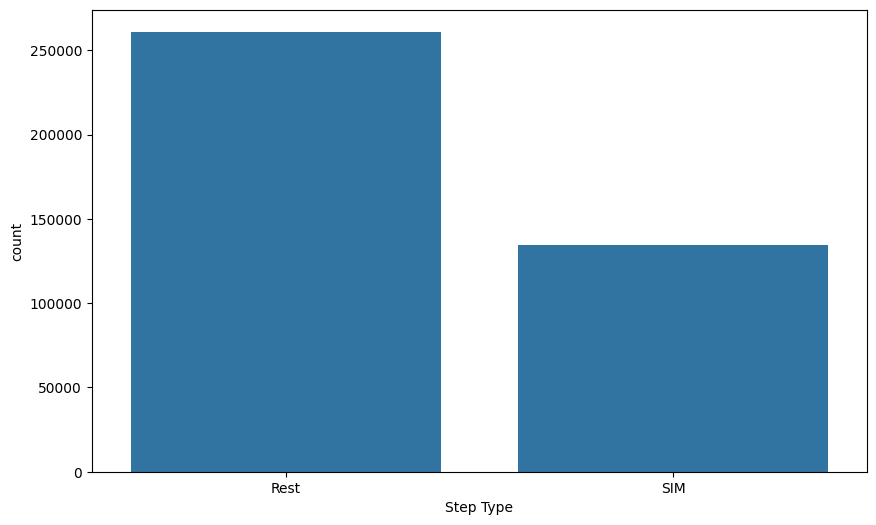

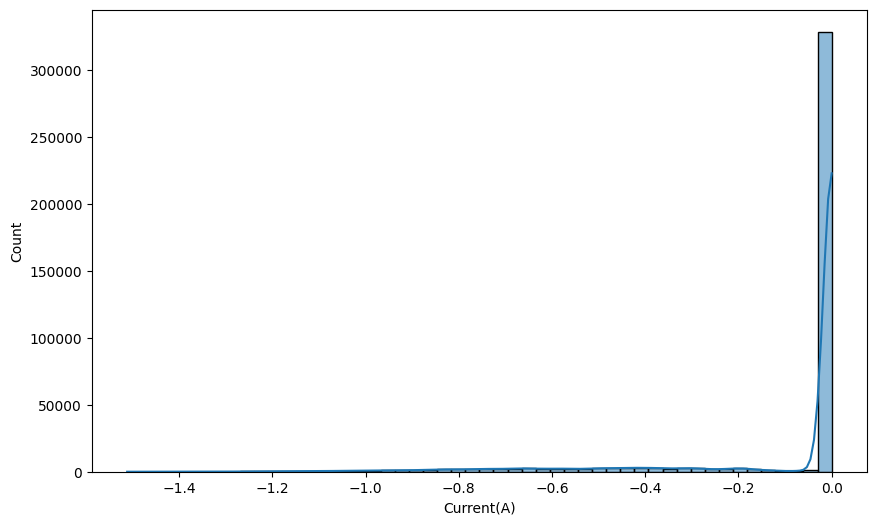

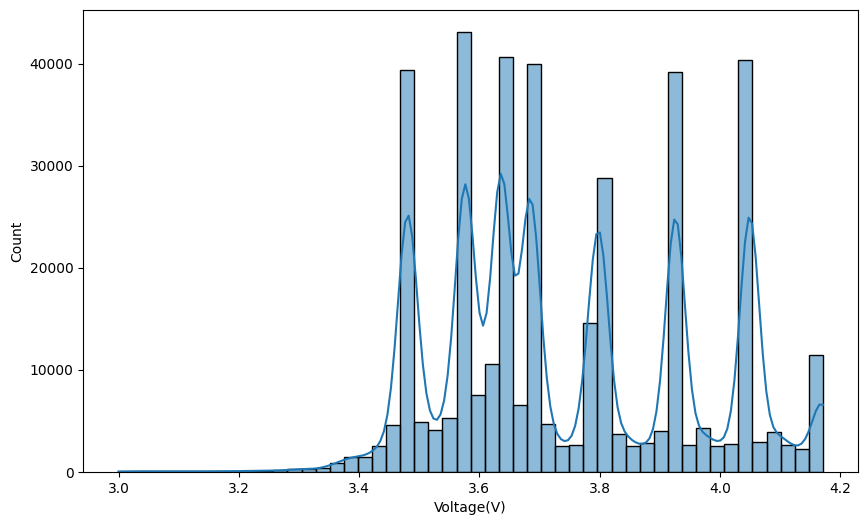

In [23]:
# plot distribution of columns using seaborn
# will do this individually for more control

# first plot distribution of 'Step Type' col (which is categorical)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Step Type')
plt.figure(figsize=(10, 6))
# then we will plot histogram distr. of current, 
sns.histplot(data=df, x='Current(A)', bins=50, kde=True)

# same as above for voltage
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Voltage(V)', bins=50, kde=True)


In [24]:
# see when the first non-zero current occurs, and when the last non-zero current occurs
first_non_zero_current = df[df['Current(A)'] != 0].iloc[0]
last_non_zero_current = df[df['Current(A)'] != 0].iloc[-1]
print(f"First non-zero current occurs at time: {first_non_zero_current['Time']}, value: {first_non_zero_current['Current(A)']}")
print(f"Last non-zero current occurs at time: {last_non_zero_current['Time']}, value: {last_non_zero_current['Current(A)']}")
indexes = df[df['Current(A)'] != 0].index
print(f"Indexes of non-zero current values: {list(indexes)}")
print(f"Indexes of first and last non-zero current values: {indexes[0]}, {indexes[-1]}")

First non-zero current occurs at time: 00:00:12, value: -0.0383344
Last non-zero current occurs at time: 00:27:37, value: -1.1466478
Indexes of non-zero current values: [9062, 9063, 9064, 9065, 9066, 9067, 9068, 9069, 9070, 9071, 9072, 9073, 9074, 9075, 9076, 9077, 9078, 9079, 9080, 9081, 9082, 9083, 9084, 9085, 9086, 9087, 9088, 9089, 9090, 9091, 9092, 9093, 9094, 9095, 9096, 9097, 9098, 9099, 9100, 9101, 9102, 9103, 9104, 9105, 9106, 9107, 9108, 9109, 9110, 9111, 9112, 9113, 9114, 9115, 9116, 9117, 9118, 9119, 9120, 9121, 9122, 9123, 9124, 9125, 9126, 9127, 9128, 9129, 9130, 9131, 9132, 9133, 9134, 9135, 9136, 9137, 9138, 9139, 9140, 9141, 9142, 9143, 9144, 9145, 9146, 9147, 9148, 9149, 9150, 9151, 9152, 9153, 9154, 9155, 9156, 9157, 9158, 9159, 9160, 9161, 9162, 9163, 9164, 9165, 9166, 9167, 9168, 9169, 9170, 9171, 9172, 9173, 9174, 9175, 9176, 9247, 9248, 9249, 9250, 9251, 9277, 9278, 9279, 9280, 9281, 9282, 9283, 9284, 9285, 9286, 9287, 9288, 9289, 9290, 9291, 9292, 9293, 9294, 92

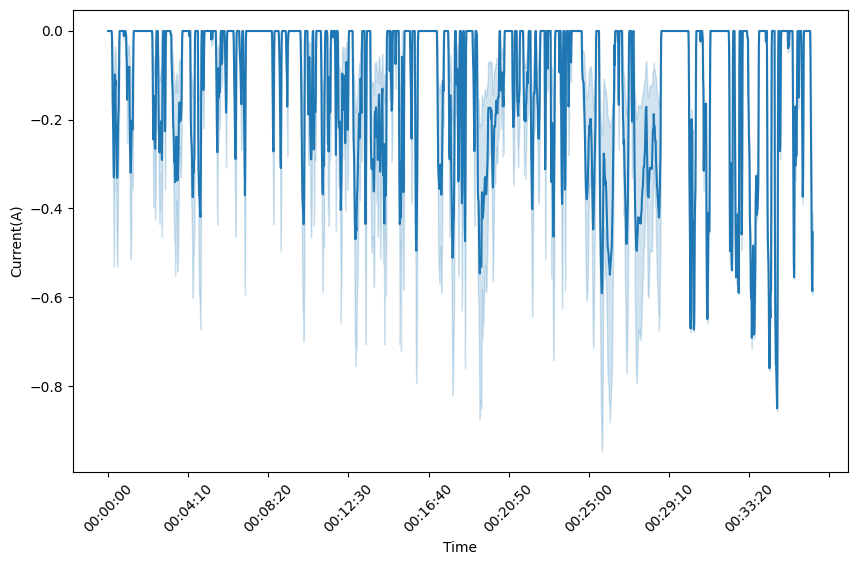

In [25]:
# now just plot current over time, to see how it changes over the course of the test
# change the df to just select the first 20,000 rows, to make the plot more readable
df = df.iloc[:20000]
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Time', y='Current(A)')
# clean up xticks and decrease the amount of them, to make the plot more readable
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))

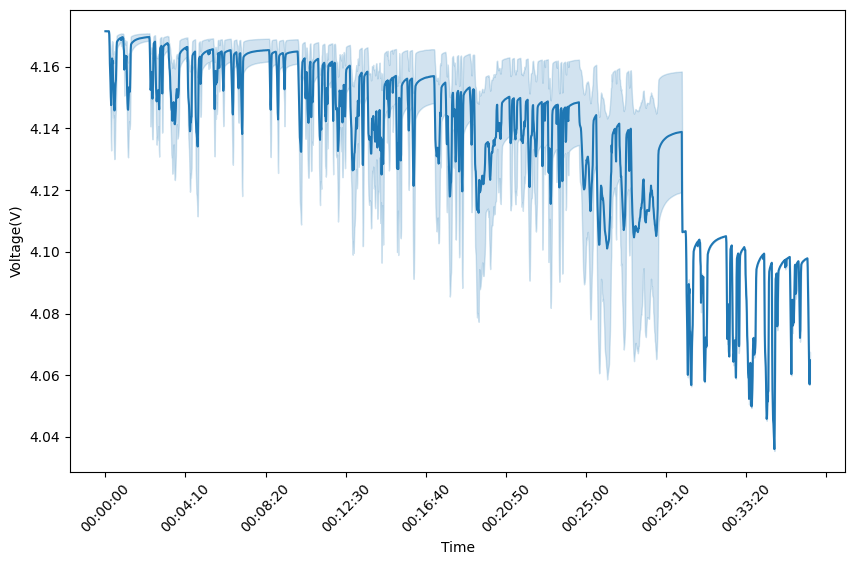

In [26]:
# do the same as above for voltage,
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Time', y='Voltage(V)')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))


In [27]:
# will now look at the mlp001params file.
mlp001params_file = PROCESSED_DATA_DIR / "MLP001_params.csv"
df = pd.read_csv(mlp001params_file)

df.columns

# want to investigate if it is feasible to interpolate on a grid or not; I suspect not.

Index(['SOC', 'R0 [Ohm]', 'R1 [Ohm]', 'R2 [Ohm]', 'tau1 [s]', 'tau2 [s]',
       'Temperature_degC'],
      dtype='object')

In [28]:
df.groupby("Temperature_degC")["SOC"].count()

Temperature_degC
5     23
10    23
15    23
25    23
40    23
Name: SOC, dtype: int64

In [29]:
# equal counts (already confirmed) doesn't rule out different SOC *values* per temperature
socs_by_temp = df.groupby("Temperature_degC")["SOC"].apply(lambda s: sorted(s.unique()))
print(socs_by_temp.apply(lambda x: x == socs_by_temp.iloc[0]))

Temperature_degC
5      True
10    False
15    False
25    False
40    False
Name: SOC, dtype: bool


In [30]:
for t, socs in socs_by_temp.items():
    print(t, min(socs), max(socs), len(socs))

5 0.05 1.01 23
10 0.05 1.01 23
15 0.05 1.01 23
25 0.05 1.01 23
40 0.05 1.01 23


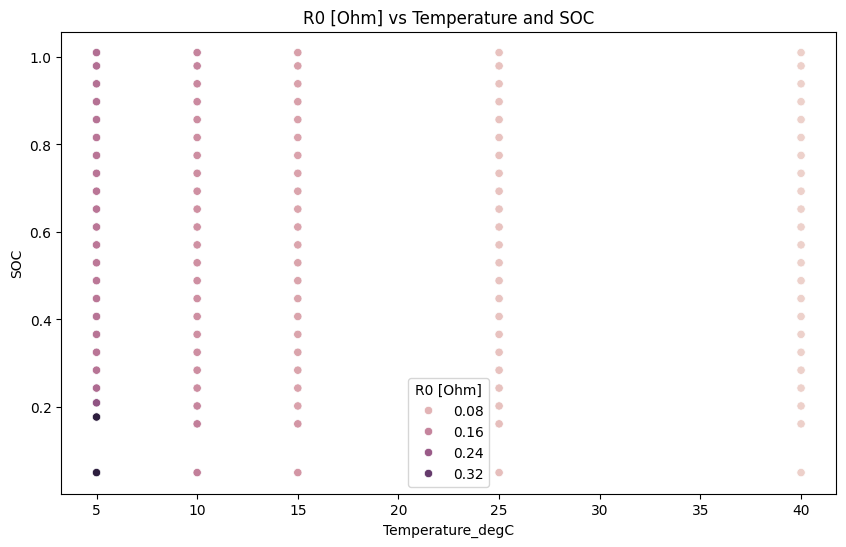

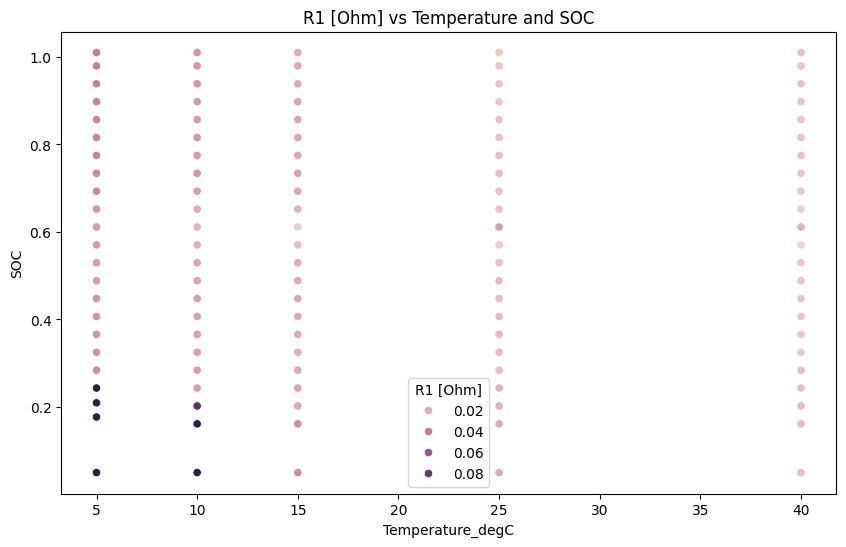

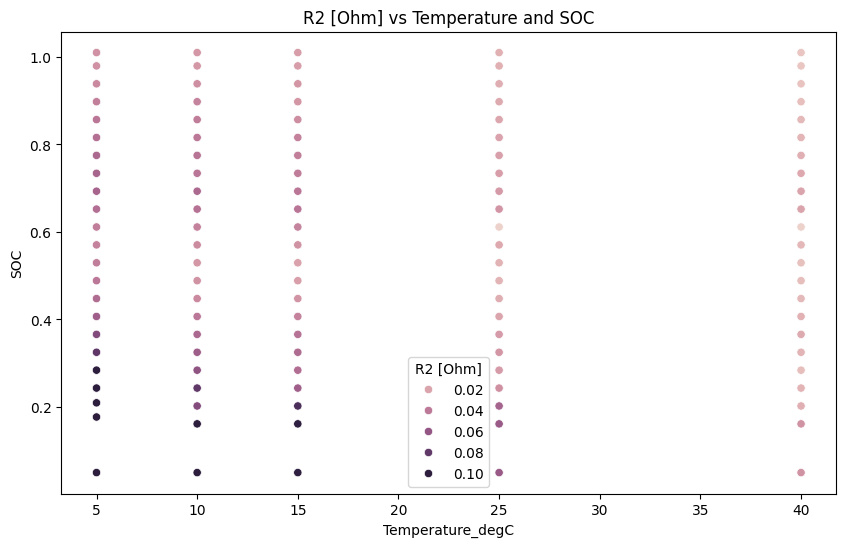

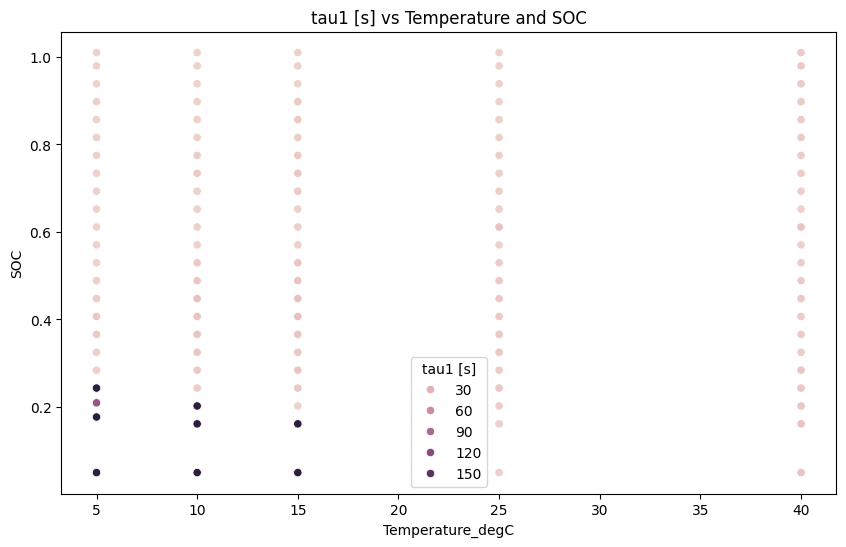

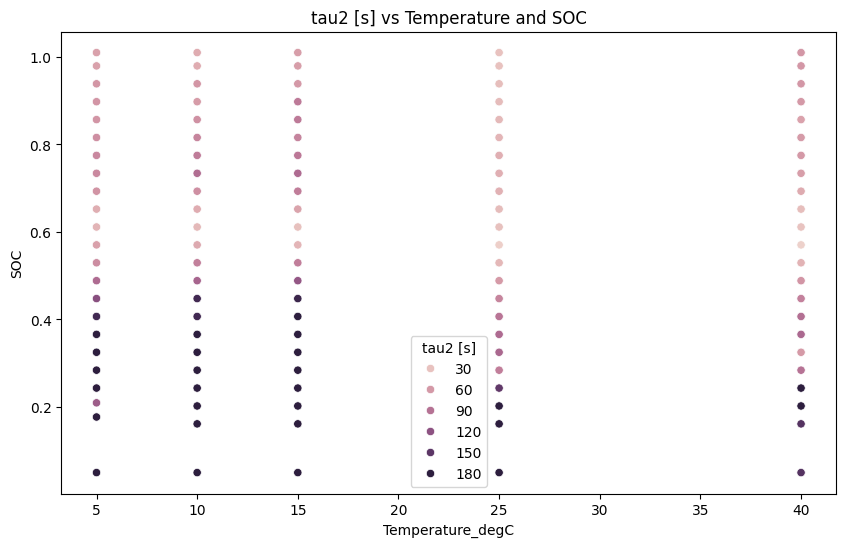

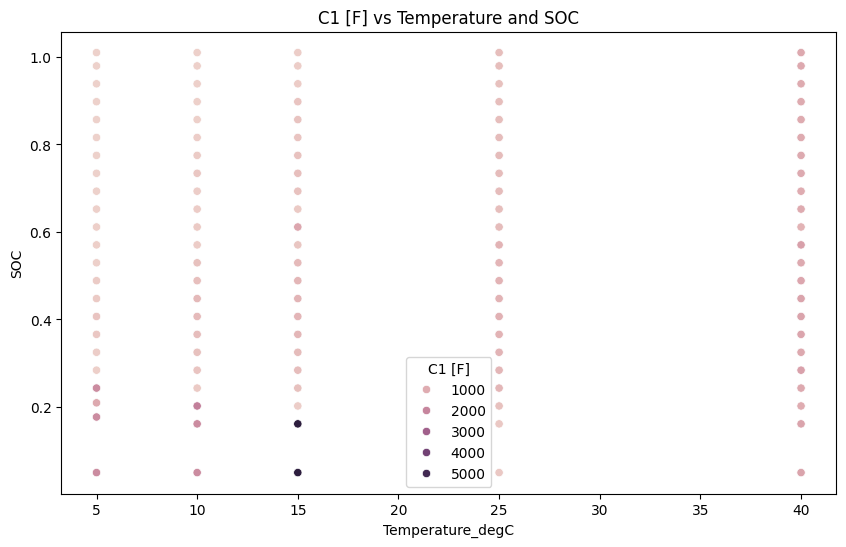

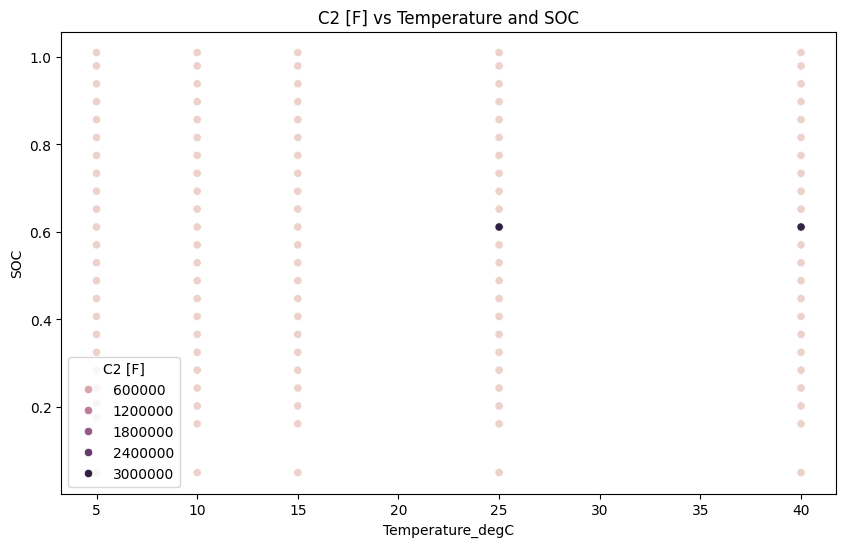

In [31]:
# plot temperature vs SOC for each parameter, to see if there is a clear relationship
# main point is to check for outliers.
params = ['R0 [Ohm]', 'R1 [Ohm]', 'R2 [Ohm]', 'tau1 [s]', 'tau2 [s]']
df["C1 [F]"] = df["tau1 [s]"] / df["R1 [Ohm]"]
df["C2 [F]"] = df["tau2 [s]"] / df["R2 [Ohm]"]
params += ["C1 [F]", "C2 [F]"]
for param in params:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x="Temperature_degC", y="SOC", hue=param)
    plt.title(f"{param} vs Temperature and SOC")
    plt.show()

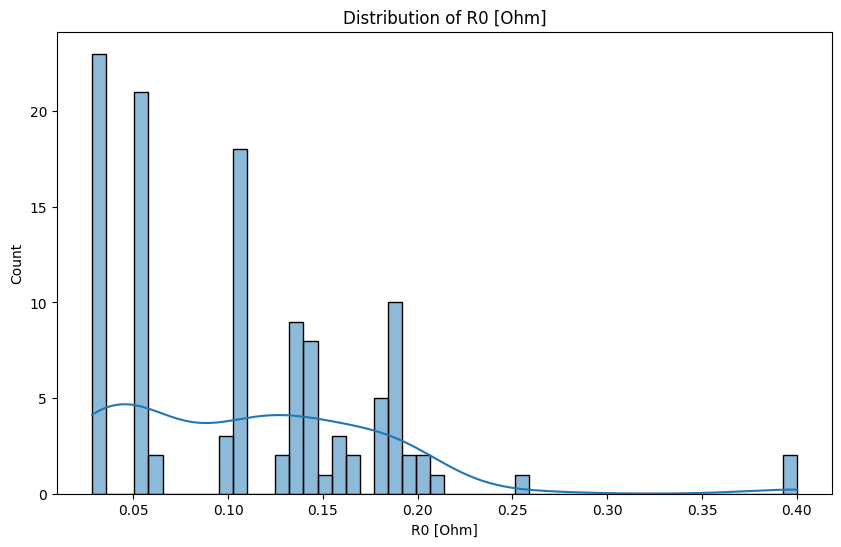

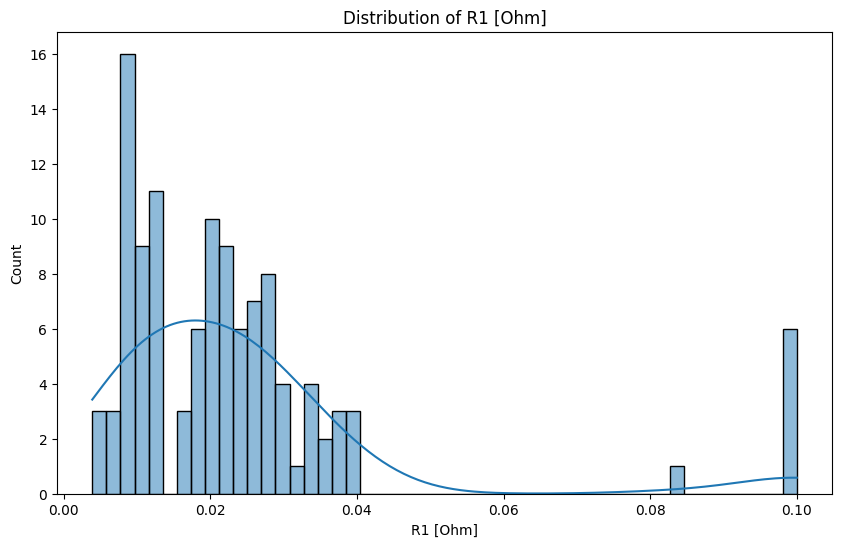

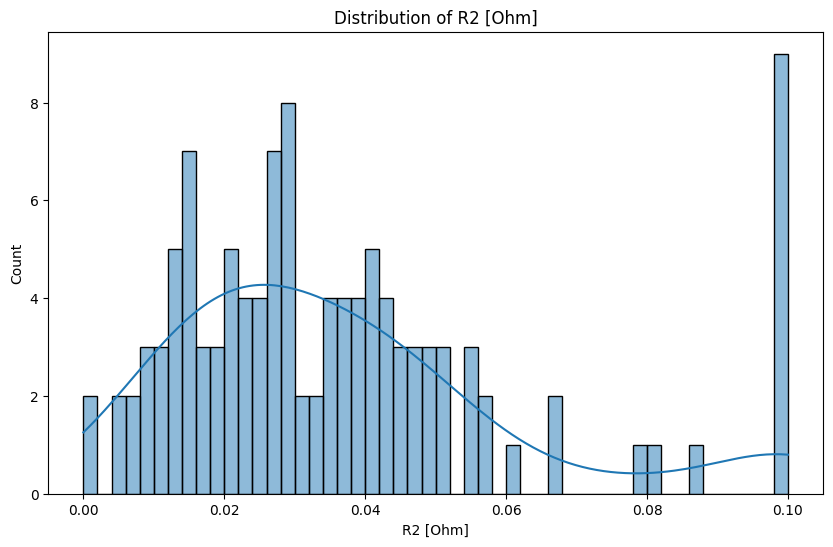

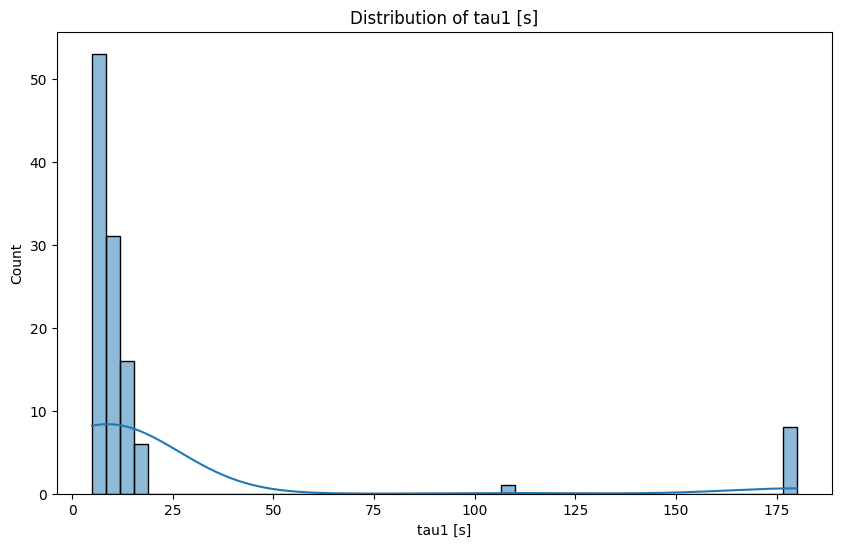

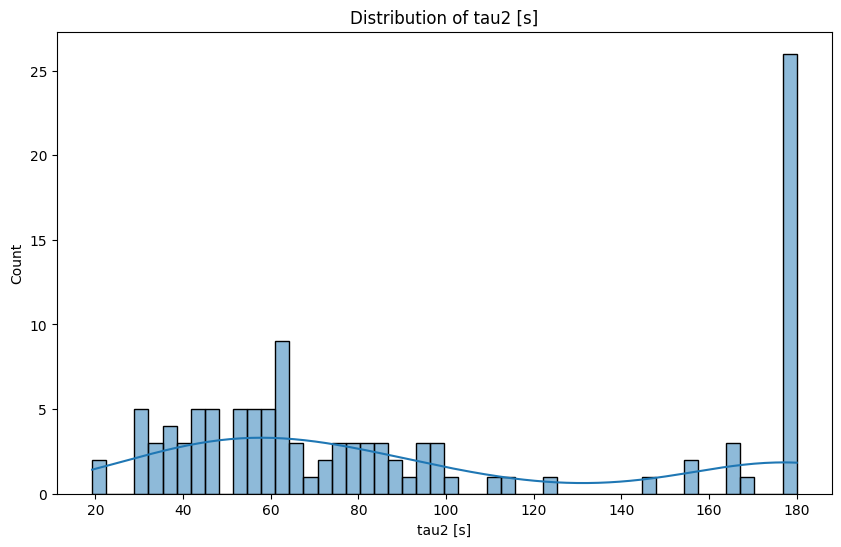

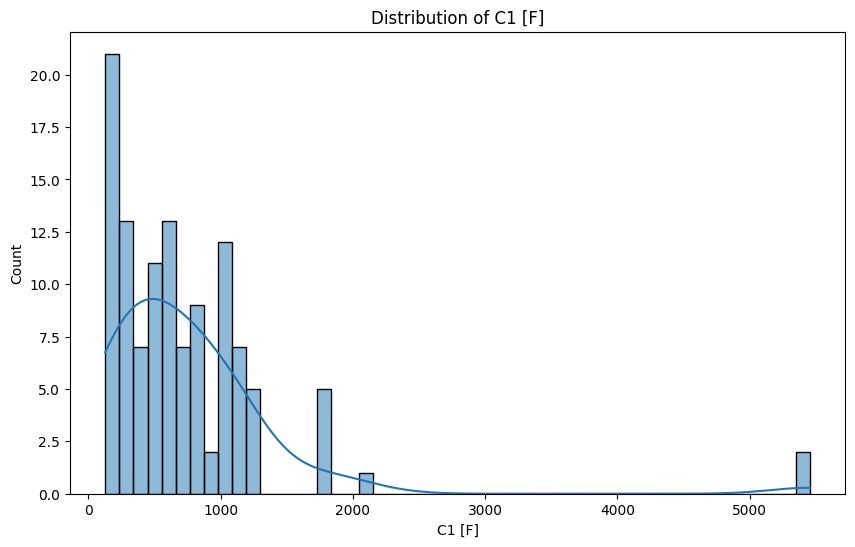

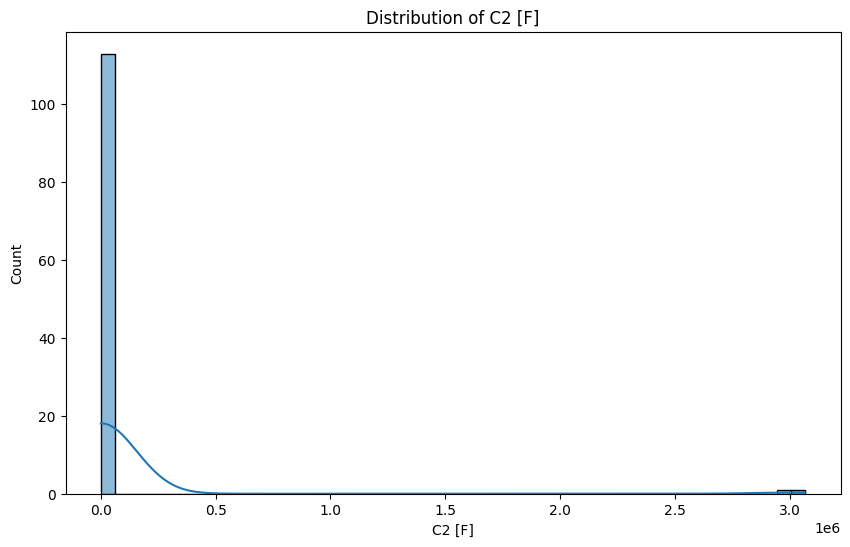

In [32]:
# plot the distribution of each parameter, to see if there are any outliers
for param in params:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=param, bins=50, kde=True)
    plt.title(f"Distribution of {param}")
    plt.show()

In [36]:
# check the drift in soc values, even with some rounding:

soc_by_T = df.groupby('Temperature_degC')['SOC'].apply(lambda x: np.sort(x.round(3).unique()))
for T, vals in soc_by_T.items():
    print(T, vals[:5])


row_5 = df[(df['Temperature_degC']==5) & (df['SOC'].round(3)==0.177)]
row_others = df[(df['Temperature_degC'].isin([10,15,25,40])) & (df['SOC'].round(3)==0.161)]
print(row_5[['SOC','R0 [Ohm]','R1 [Ohm]','R2 [Ohm]','tau1 [s]','tau2 [s]']])
print(row_others[['SOC','Temperature_degC','R0 [Ohm]','R1 [Ohm]','R2 [Ohm]','tau1 [s]','tau2 [s]']])

5 [0.05  0.177 0.209 0.243 0.284]
10 [0.05  0.161 0.202 0.243 0.284]
15 [0.05  0.161 0.202 0.243 0.284]
25 [0.05  0.161 0.202 0.243 0.284]
40 [0.05  0.161 0.202 0.243 0.284]
        SOC  R0 [Ohm]  R1 [Ohm]  R2 [Ohm]    tau1 [s]    tau2 [s]
1  0.177036  0.399927  0.099998  0.099999  179.990171  179.990752
         SOC  Temperature_degC  R0 [Ohm]  R1 [Ohm]  R2 [Ohm]    tau1 [s]  \
24  0.161358                10  0.166181  0.100000  0.100000  179.997553   
47  0.161358                15  0.126106  0.032993  0.098801  179.999150   
70  0.161350                25  0.059167  0.018978  0.057601    6.718106   
93  0.161348                40  0.031419  0.011923  0.028511   14.627318   

      tau2 [s]  
24  180.000000  
47  179.999858  
70  179.965402  
93  154.420848  


In [ ]:
# this indicates a possile issue happening at limits of sensors?
# will investigate further:

bound_candidates = df[
    (df['R1 [Ohm]'].round(4) == 0.1000) | 
    (df['R2 [Ohm]'].round(4) == 0.1000) |
    (df['tau1 [s]'].round(3) == 180.000) |
    (df['tau2 [s]'].round(3) == 180.000)
]
print(len(bound_candidates))
print(bound_candidates[['SOC','Temperature_degC','R1 [Ohm]','R2 [Ohm]','tau1 [s]','tau2 [s]']])

17
         SOC  Temperature_degC  R1 [Ohm]  R2 [Ohm]    tau1 [s]    tau2 [s]
0   0.050000                 5  0.099998  0.099999  179.990171  179.990752
1   0.177036                 5  0.099998  0.099999  179.990171  179.990752
2   0.209452                 5  0.100000  0.100000  109.375503  109.375888
3   0.243201                 5  0.099997  0.099997  179.996741  179.997010
4   0.284108                 5  0.034244  0.099994    6.682248  179.922960
23  0.050000                10  0.100000  0.100000  179.997553  180.000000
24  0.161358                10  0.100000  0.100000  179.997553  180.000000
26  0.243178                10  0.025657  0.079631    7.828835  180.000000
27  0.284087                10  0.024778  0.061492   11.230479  180.000000
46  0.050000                15  0.032993  0.098801  179.999150  179.999858
47  0.161358                15  0.032993  0.098801  179.999150  179.999858
49  0.243178                15  0.022882  0.055004   11.892603  180.000000
50  0.284087          

In [ ]:
# so 17 cases exists where, when rounded, the parameters are at their limits.